# Chapter 7 - Linear Discriminant Analysis (LDA) - Exercises


## Nguyễn Phúc Minh Châu - 22302421

## 1. Using LDA to reduce data dimension from 2 to 1 dimension

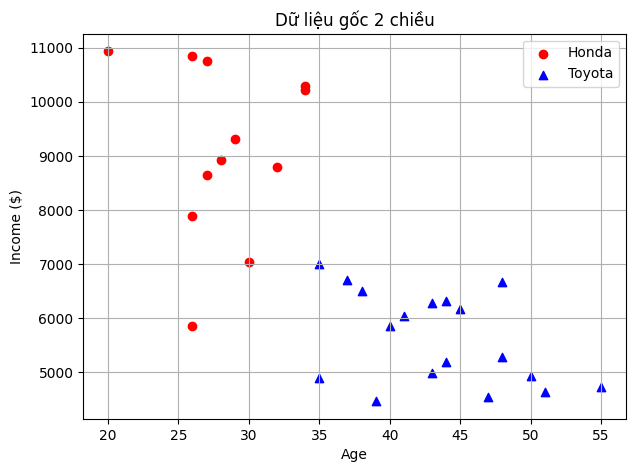

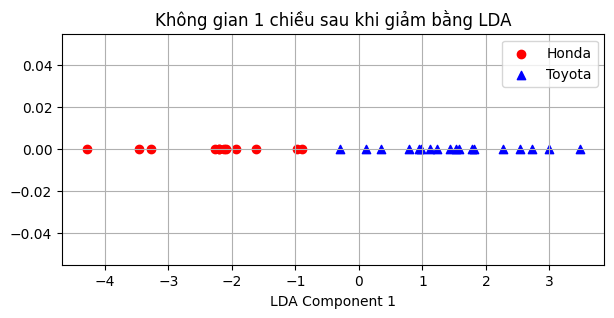

Trọng số tuyến tính (coef_): [[ 0.49617871 -0.0019535 ]]
Sai phân giữa trung bình các lớp: [[  28.25 9126.75]
 [  43.5  5618.  ]]


In [1]:
# ============================================
# Linear Discriminant Analysis (LDA)
# ============================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# -------------------------------
# 1. Tạo dữ liệu giả lập
# -------------------------------
# Hai lớp: Honda (0) và Toyota (1)
# Đặc trưng: tuổi người mua và thu nhập (2 chiều ban đầu)

# Giả định trung bình và độ lệch chuẩn khác nhau giữa hai lớp
X1_Honda_Age = np.round(28 + np.random.randn(12, 1) * 4)       # Tuổi người mua Honda
X2_Honda_Income = np.round(9000 + np.random.randn(12, 1) * 1500)  # Thu nhập (USD)

X1_Toyota_Age = np.round(40 + np.random.randn(18, 1) * 8)      # Tuổi người mua Toyota
X2_Toyota_Income = np.round(6000 + np.random.randn(18, 1) * 800)

# Ghép hai đặc trưng thành ma trận X
X = np.vstack((
    np.hstack((X1_Honda_Age, X2_Honda_Income)),
    np.hstack((X1_Toyota_Age, X2_Toyota_Income))
))

# Tạo nhãn lớp: 0 cho Honda, 1 cho Toyota
y = np.array([0]*12 + [1]*18)

# -------------------------------
# 2. Trực quan hóa dữ liệu ban đầu
# -------------------------------
plt.figure(figsize=(7,5))
plt.scatter(X[y==0,0], X[y==0,1], c='red', marker='o', label='Honda')
plt.scatter(X[y==1,0], X[y==1,1], c='blue', marker='^', label='Toyota')
plt.xlabel('Age')
plt.ylabel('Income ($)')
plt.title('Dữ liệu gốc 2 chiều')
plt.legend()
plt.grid(True)
plt.show()

# -------------------------------
# 3. Áp dụng LDA để giảm số chiều
# -------------------------------
lda = LinearDiscriminantAnalysis(n_components=1)
X_lda = lda.fit_transform(X, y)

# -------------------------------
# 4. Trực quan hóa dữ liệu sau khi giảm chiều
# -------------------------------
plt.figure(figsize=(7,3))
plt.scatter(X_lda[y==0], np.zeros_like(X_lda[y==0]), c='red', marker='o', label='Honda')
plt.scatter(X_lda[y==1], np.zeros_like(X_lda[y==1]), c='blue', marker='^', label='Toyota')
plt.xlabel('LDA Component 1')
plt.title('Không gian 1 chiều sau khi giảm bằng LDA')
plt.legend()
plt.grid(True)
plt.show()

# -------------------------------
# 5. In trọng số (hệ số phân biệt)
# -------------------------------
print("Trọng số tuyến tính (coef_):", lda.coef_)
# vector trung bình của các class
print("Sai phân giữa trung bình các lớp:", lda.means_)

## 2. Using LDA to reduce data dimension from 10 to 3 dimensions

Kích thước dữ liệu ban đầu: (200, 10)


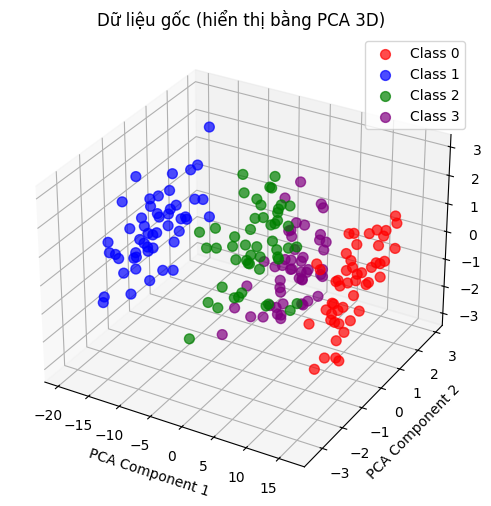

Kích thước dữ liệu sau khi giảm: (200, 3)


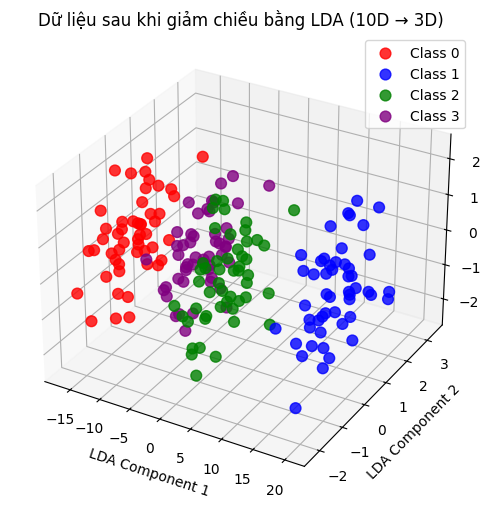

Trọng số tuyến tính (coef_):
[[ 6.24669037  4.87737314  4.97037662  4.81239177  4.4090588   3.94523759
   4.27213894  5.64536672  3.97457067  4.10260029]
 [-7.795097   -6.02588882 -6.2094037  -5.75176021 -5.44843629 -4.74691754
  -5.20276586 -7.09262199 -4.90613537 -5.28113222]
 [-0.60016328 -0.42442301 -0.27623122 -0.52793318 -0.40368545 -0.47652381
  -0.39269436 -0.76641732 -0.40658355 -0.34479727]
 [ 2.14856991  1.5729387   1.5152583   1.46730162  1.44306294  1.27820375
   1.32332128  2.21367259  1.33814825  1.5233292 ]]

Giá trị trung bình của từng lớp trong không gian gốc:
[[ 4.93000363  5.08793108  4.86162664  5.1198907   5.01915159  4.980502
   5.06597738  4.95062633  5.13622624  4.91644435]
 [-4.92276803 -5.08277587 -4.95864851 -4.90194366 -4.86015456 -5.0456002
  -5.161521   -4.8745904  -5.07388139 -4.79985522]
 [ 0.14513422  0.14815149  0.29793183  0.06059843  0.22426375 -0.10623799
  -0.01749805 -0.02147496  0.06847398  0.28550259]
 [ 2.010485    2.00244207  1.82364168  1.91

In [2]:
# ============================================
# Linear Discriminant Analysis (LDA)
# Giảm số chiều dữ liệu từ 10D → 3D
# (Có trực quan hóa dữ liệu trước và sau khi giảm)
# ============================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

# -------------------------------
# 1. Tạo dữ liệu giả lập (10 chiều, 4 lớp)
# -------------------------------
np.random.seed(42)  # để tái lập kết quả

n_samples_per_class = 50
n_features = 10
n_classes = 4

# Sinh dữ liệu Gaussian quanh các tâm khác nhau
X_class1 = np.random.randn(n_samples_per_class, n_features) + np.array([5]*n_features)
X_class2 = np.random.randn(n_samples_per_class, n_features) + np.array([-5]*n_features)
X_class3 = np.random.randn(n_samples_per_class, n_features) + np.array([0]*n_features)
X_class4 = np.random.randn(n_samples_per_class, n_features) + np.array([2]*n_features)

# Ghép tất cả lại
X = np.vstack((X_class1, X_class2, X_class3, X_class4))
y = np.array([0]*n_samples_per_class + [1]*n_samples_per_class +
             [2]*n_samples_per_class + [3]*n_samples_per_class)

print("Kích thước dữ liệu ban đầu:", X.shape)

# -------------------------------
# 2. Giảm từ 10D xuống 3D bằng PCA để visualize dữ liệu gốc
# (chỉ để trực quan, không phải mục tiêu chính)
# -------------------------------
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X)

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

colors = ['r', 'b', 'g', 'purple']
labels = ['Class 0', 'Class 1', 'Class 2', 'Class 3']

for i, color, label in zip(range(4), colors, labels):
    ax.scatter(X_pca[y==i,0], X_pca[y==i,1], X_pca[y==i,2],
               color=color, label=label, s=50, alpha=0.7)

ax.set_title('Dữ liệu gốc (hiển thị bằng PCA 3D)')
ax.set_xlabel('PCA Component 1')
ax.set_ylabel('PCA Component 2')
ax.set_zlabel('PCA Component 3')
ax.legend()
plt.show()

# -------------------------------
# 3. Áp dụng LDA để giảm số chiều từ 10 → 3
# -------------------------------
lda = LinearDiscriminantAnalysis(n_components=3)
X_lda = lda.fit_transform(X, y)

print("Kích thước dữ liệu sau khi giảm:", X_lda.shape)

# -------------------------------
# 4. Visualize dữ liệu sau khi giảm chiều (LDA 3D)
# -------------------------------
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

for i, color, label in zip(range(4), colors, labels):
    ax.scatter(X_lda[y==i,0], X_lda[y==i,1], X_lda[y==i,2],
               color=color, label=label, s=60, alpha=0.8)

ax.set_title('Dữ liệu sau khi giảm chiều bằng LDA (10D → 3D)')
ax.set_xlabel('LDA Component 1')
ax.set_ylabel('LDA Component 2')
ax.set_zlabel('LDA Component 3')
ax.legend()
plt.show()

# -------------------------------
# 5. In thông tin quan trọng
# -------------------------------
print("Trọng số tuyến tính (coef_):")
print(lda.coef_)

print("\nGiá trị trung bình của từng lớp trong không gian gốc:")
print(lda.means_)


## What is the purpose of dimensionality reduction?

Based on the content of the notebook, the purposes of dimensionality reduction are:

- **Reduce the number of features:** Dimensionality reduction helps decrease the number of variables (features) in the dataset. This can make machine learning models faster and more efficient.

- **Remove noise and redundant data:** By retaining only the most important features, dimensionality reduction helps eliminate noise and redundant information that can degrade model performance.

- **Data visualization**: When data has more than 3 dimensions, visualization becomes difficult. Reducing dimensions to 2 or 3 allows us to plot graphs and better understand the data structure, as seen in the examples using PCA and LDA in the notebook.

- **Reduce memory and computational requirements**: Lower dimensional data requires less memory to store and fewer computational resources to process.

- **Help machine learning algorithms perform better:** Some machine learning algorithms perform poorly with high-dimensional data (the curse of dimensionality). Dimensionality reduction can improve the performance of these algorithms.

In this notebook, we saw how LDA was used to reduce data dimensionality from 2D to 1D and from 10D to 3D, and then visualize the results to see the separation of classes after dimensionality reduction.